# Modelado Estocástico
## Ejercitación 5

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

### Generamos los 100 números aleatorios ("ruido blanco") con distribución normal estándar.

In [ ]:
n = 100
aleatorios = np.random.standard_normal(n)

### Generamos los procesos AR(1) con los valores indicados.

Es decir el proceso:

 $y_t = 0.5  y_{t-1} + \epsilon_t$

 y el proceso:

  $y_t = 0.9  y_{t-1} + \epsilon_t$


 Con $\epsilon_t$ corresponde a los valores de ruidos blanco generados previamente. El valor inicial será $y_1 = \epsilon_1$

In [ ]:
def proceso_ar(rho, y_prev, error):
    return rho * y_prev + error

In [ ]:
def simular_proceso_ar(rho, n,errores):
    y = np.zeros(n)
    y[0] = errores[0]
    for i in range(1, n):
        error = errores[i]
        y[i] = proceso_ar(rho, y[i-1], error)
    return y

In [ ]:
rho = 0.5
ar_0_5 = simular_proceso_ar(rho, n, aleatorios)
rho2 = 0.9
ar_0_9 = simular_proceso_ar(rho2, n, aleatorios)

Para facilitar la visualización, generamos un df con las tres columnas generadas:

In [ ]:
df = pd.DataFrame({'white_noise':aleatorios,'AR(1)0.5':ar_0_5,'AR(1)0.9':ar_0_9})
df.head()

,white_noise,AR(1)0.5,AR(1)0.9
0,0.521459,0.521459,0.521459
1,-1.326246,-1.065516,-0.856932
2,0.131902,-0.400856,-0.639337
3,-0.921733,-1.122161,-1.497136
4,2.041199,1.480119,0.693777


### Graficamos:

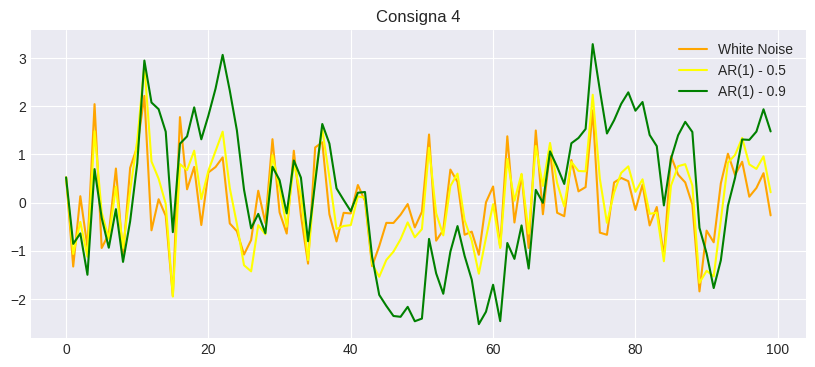

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df["white_noise"], label="White Noise", color='orange')
plt.plot(df["AR(1)0.5"], label="AR(1) - 0.5", color='yellow')
plt.plot(df["AR(1)0.9"], label="AR(1) - 0.9", color='green')

plt.title("Consigna 4")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"Media de white noise: {df['white_noise'].mean()} \nMedia de AR(1) 0.5: {df['AR(1)0.5'].mean()} \nMedia de AR(1) 0.9: {df['AR(1)0.9'].mean()}")

Media de white noise: 0.03527780072035898 
Media de AR(1) 0.5: 0.06841663258528427 
Media de AR(1) 0.9: 0.21998297812419915


5. Para generar diferentes procesos podemos volver a correr las celdas desde la generación del ruido blanco. No se notan variaciones significativas.

6. Los 3 procesos tienen media $\approx 0$.
El ruido blanco, basicamente por definición.
Y los dos AR(1), (recuerden de la clase que los podemos escribir como un MA infinito, y cada uno de los epsilon tiene esperanza cero) tendrán media
igual a cero. Noten que si hubiera una constante "c" en el AR(1), la media ya no sería 0. Pero sería constante. Si el proceso autorregresivo es débilmente estacionario, entonces la media existe.
En el gráfico podemos apreciar que estos procesos si bien pueden distanciarse de la media, en el tiempo retornan a la media.

### Comparativa por los procesos generados desde las bibliotecas

A continuación generamos los procesos de forma automática y realizamos la misma visualización.

In [ ]:
ar1_05_params = np.array([1, -rho])
ar1_09_params = np.array([1, -rho2])
ma_params_base = np.array([1])
ar1_05_process = ArmaProcess(ar1_05_params, ma_params_base)
ar1_09_process = ArmaProcess(ar1_09_params, ma_params_base)


Con el parámetro `distrvs` podemos utilizar los mismos residuos aleatorios que generamos previamente.

In [ ]:
u_ar1_05 = ar1_05_process.generate_sample(
    nsample=100,
    distrvs=lambda size: aleatorios
)

u_ar1_09 = ar1_09_process.generate_sample(
    nsample=100,
    distrvs=lambda size: aleatorios
)

Organizamos la información en un DataFrame para comparar los resultados de la generación utilizando la biblioteca y el proceso manual, ambos con los mismos residuos:

In [ ]:
df_stats = pd.DataFrame({'white_noise':aleatorios,'AR(1)0.5':u_ar1_05,'AR(1)0.9':u_ar1_09})
df_stats.head()

,white_noise,AR(1)0.5,AR(1)0.9
0,0.521459,0.521459,0.521459
1,-1.326246,-1.065516,-0.856932
2,0.131902,-0.400856,-0.639337
3,-0.921733,-1.122161,-1.497136
4,2.041199,1.480119,0.693777


In [ ]:
df.equals(df_stats)

True

#### Regresiones OLS

7. Estimamos los procesos AR(1) mediante OLS

Para cada proceso estimamos:

$$
y_t = \rho y_{t-1} + u_t
$$

sin constante.

Generamos los rezagos y eliminamos la primera observación, que no tiene rezago

In [ ]:
df["AR(1)0.5_lag"] = df["AR(1)0.5"].shift(1)
df["AR(1)0.9_lag"] = df["AR(1)0.9"].shift(1)
df_reg = df.dropna()

Generamos ambas regresiones y observamos sus resultados:

In [ ]:
X_05 = df_reg[["AR(1)0.5_lag"]]
y_05 = df_reg["AR(1)0.5"]

modelo_05 = sm.OLS(y_05, X_05).fit()

print("AR(1) con rho = 0.5")
print(modelo_05.summary())
print("**" * 50)

X_09 = df_reg[["AR(1)0.9_lag"]]
y_09 = df_reg["AR(1)0.9"]

modelo_09 = sm.OLS(y_09, X_09).fit()

print("AR(1) con rho = 0.9")
print(modelo_09.summary())


AR(1) con rho = 0.5
                                 OLS Regression Results                                
Dep. Variable:               AR(1)0.5   R-squared (uncentered):                   0.151
Model:                            OLS   Adj. R-squared (uncentered):              0.142
Method:                 Least Squares   F-statistic:                              17.41
Date:                Sat, 15 Aug 2026   Prob (F-statistic):                    6.53e-05
Time:                        01:43:29   Log-Likelihood:                         -123.19
No. Observations:                  99   AIC:                                      248.4
Df Residuals:                      98   BIC:                                      251.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [ ]:
print("Estimación de rho para AR(1) 0.5:", modelo_05.params.iloc[0])
print("Estimación de rho para AR(1) 0.9:", modelo_09.params.iloc[0])

Estimación de rho para AR(1) 0.5: 0.3878321697565399
Estimación de rho para AR(1) 0.9: 0.8276005304079338


### ACF y PACF
8.

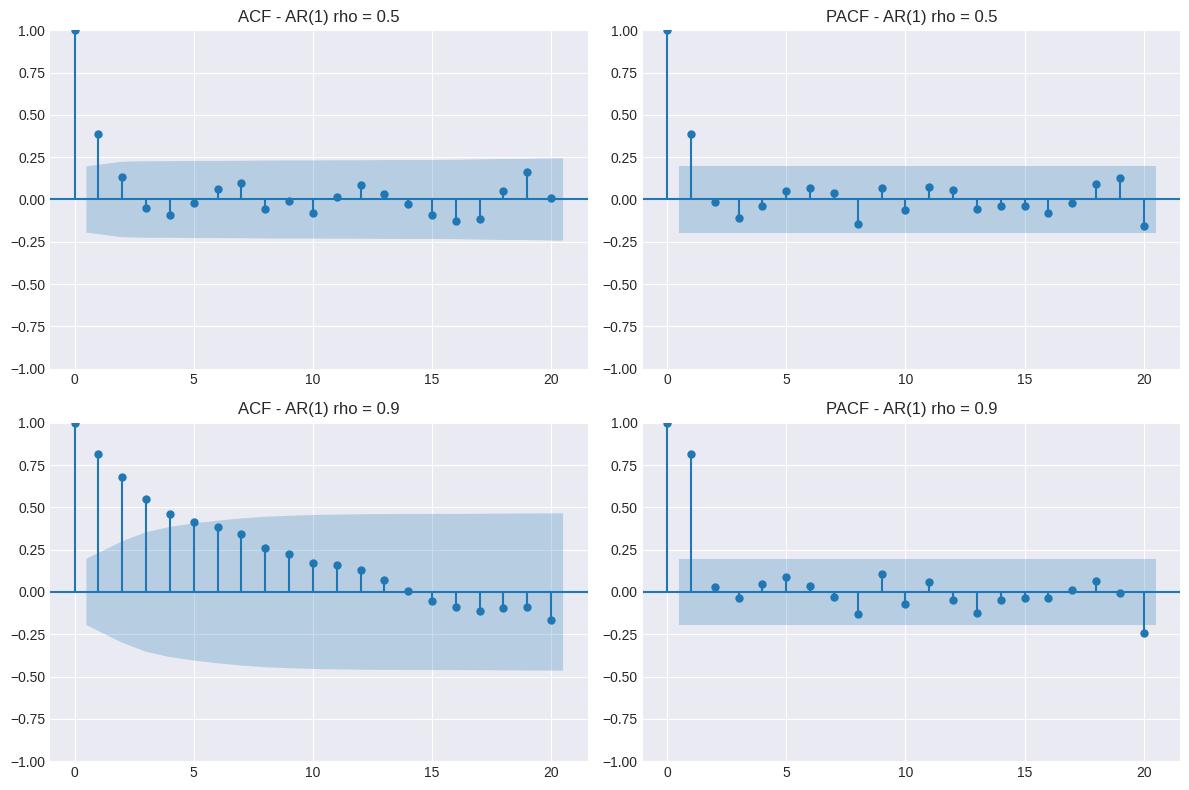

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(df["AR(1)0.5"], lags=20, ax=axes[0, 0])
axes[0, 0].set_title("ACF - AR(1) rho = 0.5")

plot_pacf(df["AR(1)0.5"], lags=20, ax=axes[0, 1])
axes[0, 1].set_title("PACF - AR(1) rho = 0.5")

plot_acf(df["AR(1)0.9"], lags=20, ax=axes[1, 0])
axes[1, 0].set_title("ACF - AR(1) rho = 0.9")

plot_pacf(df["AR(1)0.9"], lags=20, ax=axes[1, 1])
axes[1, 1].set_title("PACF - AR(1) rho = 0.9")

plt.tight_layout()
plt.show()

### 9. Introducimos un shock

En Excel, si modificamos la observación 15 del ruido blanco,
los procesos AR(1) se recalculan a partir de ese momento.

Hacemos lo mismo en Python: modificamos epsilon_15 por 3
y volvemos a generar los dos procesos AR(1).

In [ ]:
aleatorios_shock = aleatorios.copy()

aleatorios_shock[14] = 3

ar_0_5_shock = ar1_05_process.generate_sample(
    nsample=100,
    distrvs=lambda size: aleatorios_shock
)

ar_0_9_shock = ar1_09_process.generate_sample(
    nsample=100,
    distrvs=lambda size: aleatorios_shock
)

df_shock = pd.DataFrame({
    "white_noise": aleatorios_shock,
    "AR(1) rho=0.5": ar_0_5_shock,
    "AR(1) rho=0.9": ar_0_9_shock
})

Graficamos comparativamente

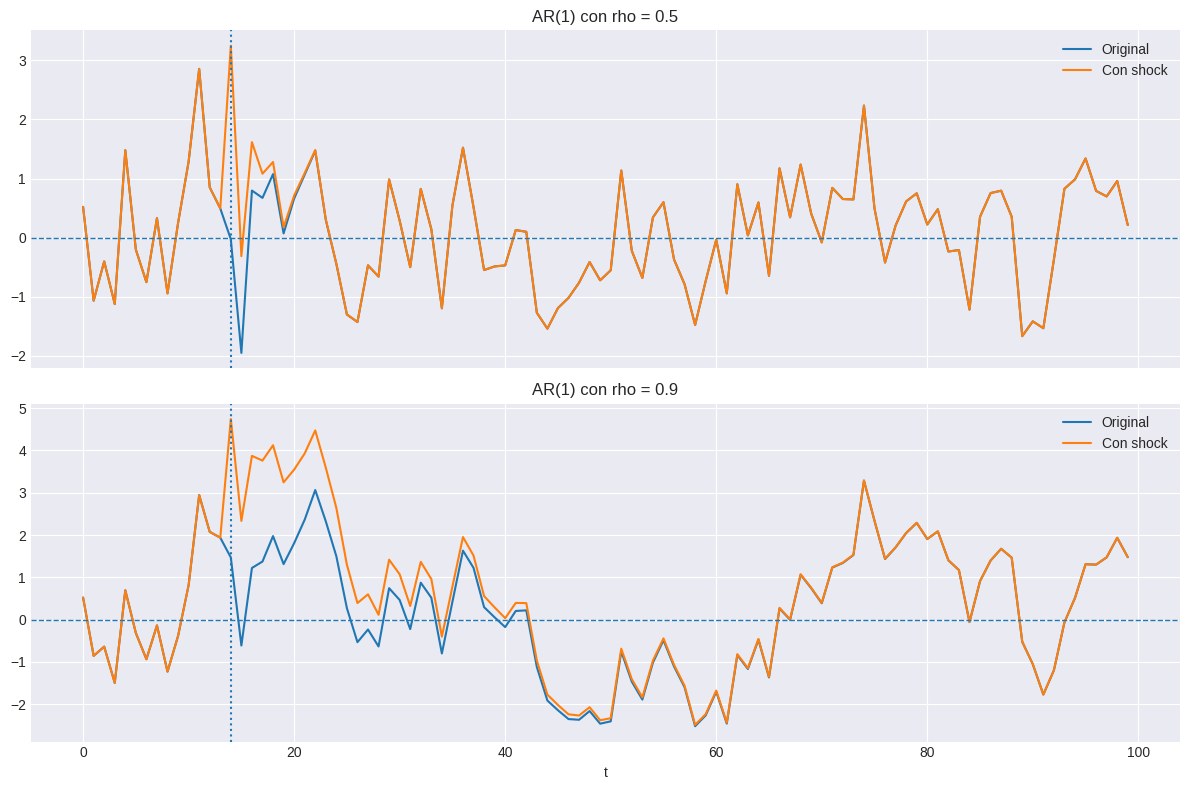

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(ar_0_5, label="Original")
axes[0].plot(ar_0_5_shock, label="Con shock")
axes[0].axvline(14, linestyle=":")
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("AR(1) con rho = 0.5")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ar_0_9, label="Original")
axes[1].plot(ar_0_9_shock, label="Con shock")
axes[1].axvline(14, linestyle=":")
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_title("AR(1) con rho = 0.9")
axes[1].legend()
axes[1].grid(True)

plt.xlabel("t")
plt.tight_layout()
plt.show()

### 10. Random Walk

Ahora hacemos rho = 1:

$$
y_t = y_{t-1} + \epsilon_t
$$

Este proceso es un random walk.

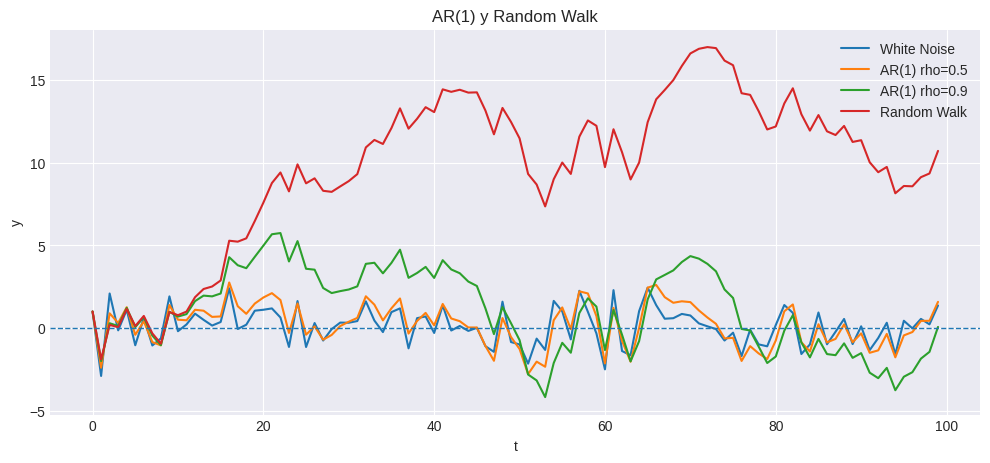

In [ ]:
random_walk = simular_proceso_ar(1, n, aleatorios)

df_rw = pd.DataFrame({
    "white_noise": aleatorios,
    "AR(1) rho=0.5": ar_0_5,
    "AR(1) rho=0.9": ar_0_9,
    "Random Walk": random_walk
})

plt.figure(figsize=(12, 5))

plt.plot(
    df_rw["white_noise"],
    label="White Noise"
)

plt.plot(
    df_rw["AR(1) rho=0.5"],
    label="AR(1) rho=0.5"
)

plt.plot(
    df_rw["AR(1) rho=0.9"],
    label="AR(1) rho=0.9"
)

plt.plot(
    df_rw["Random Walk"],
    label="Random Walk"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("AR(1) y Random Walk")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

### 11. Opcional: ¿qué ocurre cuando rho se acerca a 1?

Probamos distintos valores:

0.95, 0.97, 0.99, 1.01 y 1.05.

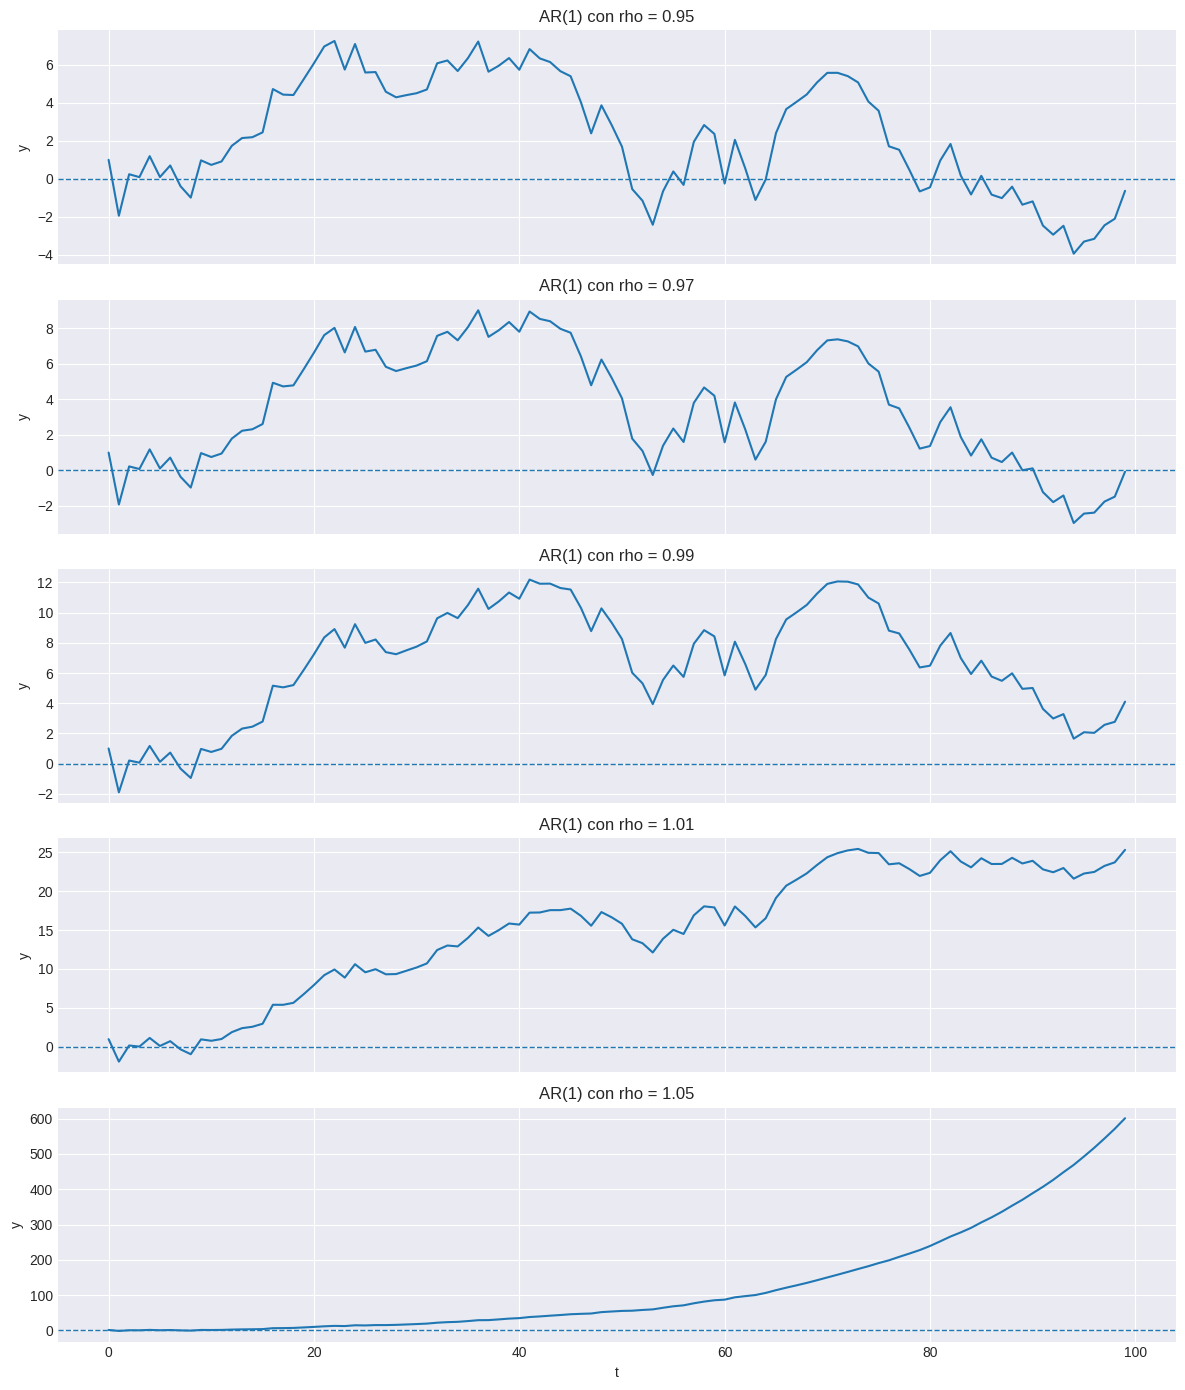

In [ ]:
rhos = [0.95, 0.97, 0.99, 1.01, 1.05]

fig, axes = plt.subplots(
    len(rhos),
    1,
    figsize=(12, 14),
    sharex=True
)

for ax, rho in zip(axes, rhos):

    proceso = simular_proceso_ar(rho, n, aleatorios)

    ax.plot(proceso)
    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_title(f"AR(1) con rho = {rho}")
    ax.set_ylabel("y")
    ax.grid(True)

axes[-1].set_xlabel("t")

plt.tight_layout()
plt.show()

### 12. Opcional: valores negativos de rho

Probamos distintos valores negativos de rho.

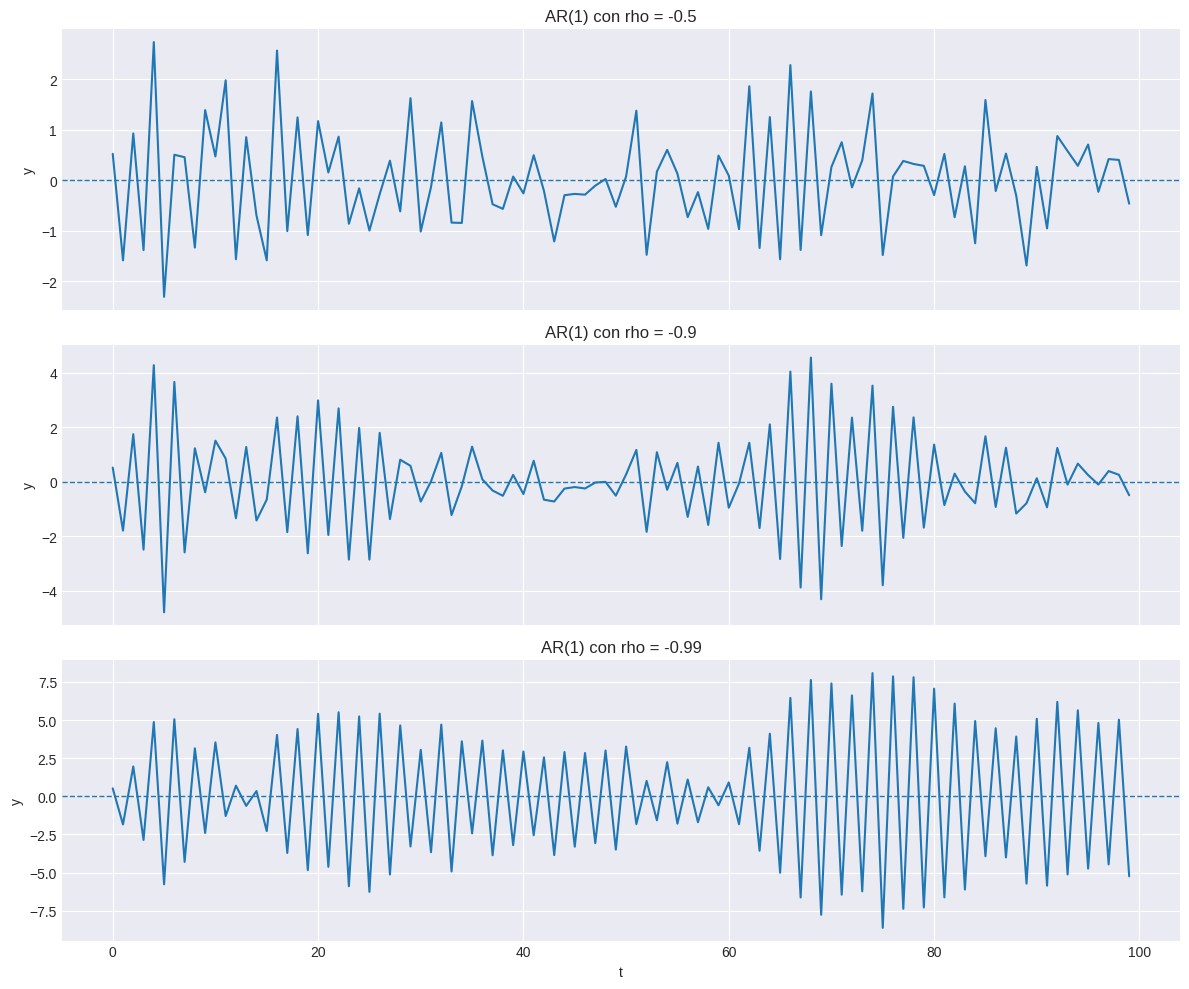

In [ ]:
rhos_negativos = [-0.5, -0.9, -0.99]

fig, axes = plt.subplots(
    len(rhos_negativos),
    1,
    figsize=(12, 10),
    sharex=True
)

for ax, rho in zip(axes, rhos_negativos):

    proceso = simular_proceso_ar(rho, n, aleatorios)

    ax.plot(proceso)
    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_title(f"AR(1) con rho = {rho}")
    ax.set_ylabel("y")
    ax.grid(True)

axes[-1].set_xlabel("t")

plt.tight_layout()
plt.show()